# FLEX-Med — Ablation Study: Homogeneous FL Baseline (EfficientNet-B0)

## Latest Results (last run)

```
FEDERATED LEARNING — POST-FL EVALUATION METRICS (Public Test Set)

Client       Model                Accuracy         F1    Precision  Sensitivity  Specificity   ROC-AUC    PR-AUC
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Client 1 (B0) efficientnet_b0        77.0%     80.7%       78.1%       83.5%       68.1%       83.8%     84.8%
Client 2 (B0) efficientnet_b0        80.7%     84.1%       80.1%       88.5%       70.0%       86.0%     86.7%
Client 3 (B0) efficientnet_b0        79.2%     82.1%       81.4%       82.8%       74.2%       86.5%     87.9%
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
AVERAGE                             78.9%     82.3%       79.8%       84.9%       70.8%       85.4%     86.5%
```

## Latest Logs (last run)

- Logs are written during the simulation run and can be viewed in the **`# LOGS`** section below.
- The run also persists a summary JSON (see log output around: `Summary saved: /content/drive/MyDrive/College/FLEX-Med/training_summary.json`).

---

## Study Description

This notebook is an **ablation study** evaluating a **homogeneous federated learning setup** where all clients use the identical model architecture (`efficientnet_b0`).

**Ablation variable:** Model architecture homogeneity.
**What is changed:** All clients are forced to use `efficientnet_b0` instead of a mix of B0, B1, and B2. The FastAPI orchestrator has been removed for manual execution.
**What is unchanged:** The FL strategy, data partitioning (Dirichlet alpha=1.5), knowledge distillation, progressive unfreezing, and all other hyperparameters.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Setup & Dependencies

In [2]:
import sys
import os

from google.colab import drive
drive.mount('/content/drive')

# --- Configuration: Set your project path here ---
PROJECT_ROOT = "/content/drive/MyDrive/College/FLEX-Med/federated_learning"

%cd {PROJECT_ROOT}

# Install dependencies
!pip install fastapi uvicorn pyngrok==7.0.5 nest-asyncio 'flwr[simulation]==1.23.0' flwr_datasets datasets scikit-learn -q

# Ensure package structure exists
os.makedirs("flex_med/utils", exist_ok=True)

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/College/FLEX-Med/federated_learning


---
## 2. Configuration (`flex_med/utils/config.py`)

Standalone configuration — no dependency on `app.config`. All paths are resolved relative to the project root or overridden via environment variables.

In [3]:
%%writefile flex_med/utils/__init__.py
# flex_med/utils package

Overwriting flex_med/utils/__init__.py


In [4]:
%%writefile flex_med/__init__.py
# flex_med package

Overwriting flex_med/__init__.py


In [5]:
%%writefile flex_med/utils/config.py
"""Standalone configuration for FLEX-Med FL simulation (Colab-compatible)."""
import os
from pathlib import Path

# ============================================================================
# PATH RESOLUTION
# ============================================================================
_CURRENT_FILE = Path(__file__).resolve()
_FL_DIR = _CURRENT_FILE.parent.parent.parent  # flex_med/utils/config.py -> federated_learning/
_PROJECT_ROOT = _FL_DIR.parent  # federated_learning/ -> FLEX-Med/

BASE_PATH = os.getenv("BASE_PATH", str(_PROJECT_ROOT))
PROJECT_DIR = str(_FL_DIR)

# ============================================================================
# LOGS
# ============================================================================
SIMULATION_LOG_PATH = os.getenv(
    "SIMULATION_LOG_PATH",
    str(_FL_DIR / "flex_med" / "utils" / "simulation_run.log")
)

# ============================================================================
# CLIENT CONFIGURATION
# ============================================================================
CLIENT_INFO_FILE_PATH = os.getenv(
    "FLEX_MED_CONFIG_FILE",
    str(_FL_DIR / "flex_med" / "utils" / "client_data.json")
)

# ============================================================================
# PYPROJECT.TOML
# ============================================================================
PYPROJECT_PATH = str(_FL_DIR / "pyproject.toml")

# ============================================================================
# DATASETS
# ============================================================================
DATASET_FILE_PATH = os.getenv(
    "DATASET_FILE_PATH",
    str(Path(BASE_PATH) / "datasets" / "cnmc")
)
PUBLIC_ANCHOR_DATASET_PATH = os.getenv(
    "PUBLIC_ANCHOR_DATASET_PATH",
    str(Path(DATASET_FILE_PATH) / "cnmc_public_anchor")
)
PUBLIC_TEST_DATASET_PATH = os.getenv(
    "PUBLIC_TEST_DATASET_PATH",
    str(Path(DATASET_FILE_PATH) / "cnmc_public_test")
)
LOCAL_TRAIN_DATASET_PATH = os.getenv(
    "LOCAL_TRAIN_DATASET_PATH",
    str(Path(DATASET_FILE_PATH) / "cnmc_local_train")
)

# ============================================================================
# MODEL CHECKPOINTS
# ============================================================================
MODEL_CHECKPOINT_FILE_PATH = os.getenv(
    "CHECKPOINTS_PATH",
    str(Path(BASE_PATH) / "checkpoints")
)

# ============================================================================
# METRICS & GRAPHS
# ============================================================================
GRAPHS_OUTPUT_DIR = os.getenv(
    "GRAPHS_OUTPUT_DIR",
    str(Path(BASE_PATH) / "graphical_visualisation")
)

# ============================================================================
# MODEL CONSTRAINTS
# ============================================================================
NUM_CLASSES = 2
IMG_SIZE = 256

# ============================================================================
# SIMULATION RUNNER
# ============================================================================
RUN_SIMULATION_SHELL_FILE_PATH = str(_FL_DIR / "flex_med" / "utils" / "run_simulation.sh")

# ============================================================================
# LOSS WEIGHTING
# ============================================================================
TRAIN_LOSS_WEIGHT = float(os.getenv("FLEX_MED_TRAIN_LOSS_WEIGHT", "0.72"))
DISTILL_LOSS_WEIGHT = float(os.getenv("FLEX_MED_DISTILL_LOSS_WEIGHT", "0.28"))

# ============================================================================
# DIRICHLET PARTITIONING
# ============================================================================
DIRICHLET_ALPHA = float(os.getenv("FLEX_MED_DIRICHLET_ALPHA", "1.5"))
DIRICHLET_SEED = int(os.getenv("FLEX_MED_DIRICHLET_SEED", "42"))
DIRICHLET_MIN_PARTITION_SIZE = int(os.getenv("FLEX_MED_DIRICHLET_MIN_PARTITION_SIZE", "400"))

# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================
MINORITY_BOOST = float(os.getenv("FLEX_MED_MINORITY_BOOST", "0.90"))

DISTILL_WEIGHT_BASE = float(os.getenv("FLEX_MED_DISTILL_WEIGHT", "0.80"))
DISTILL_DECAY_RATE = float(os.getenv("FLEX_MED_DISTILL_DECAY", "0.10"))

WEIGHT_DECAY = float(os.getenv("FLEX_MED_WEIGHT_DECAY", "0.02"))

Overwriting flex_med/utils/config.py


---
## 3. Helper Utilities (`flex_med/utils/helpers.py`)

Client config loading, model creation, freeze/unfreeze strategy, database persistence.

In [6]:
%%writefile flex_med/utils/helpers.py
import os
import json
from datetime import datetime
from typing import Dict, List, Optional
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B1_Weights, EfficientNet_B2_Weights
from pathlib import Path
from flex_med.utils.config import (
    LOCAL_TRAIN_DATASET_PATH, DIRICHLET_ALPHA, DIRICHLET_SEED, CLIENT_INFO_FILE_PATH, NUM_CLASSES)

# <----------------------------- CONSTANTS & GLOBAL VARIABLES ----------------------------->
SIMULATION_ID = 1

METRICS_FILE = os.path.join(os.path.dirname(CLIENT_INFO_FILE_PATH), "client_simulation_metrics.json")

def _load_local_metrics():
    if os.path.exists(METRICS_FILE):
        with open(METRICS_FILE, 'r') as f:
            return json.load(f)
    return {}

def _save_local_metrics(data):
    os.makedirs(os.path.dirname(METRICS_FILE), exist_ok=True)
    with open(METRICS_FILE, 'w') as f:
        json.dump(data, f, indent=2)

def get_simulation_id() -> Optional[int]:
    return SIMULATION_ID

# <----------------------------- PATH UTILITIES ----------------------------->
def sanitize_client_paths(clients: List[Dict]) -> List[Dict]:
    fl_root = Path(__file__).parent.parent.parent
    for client in clients:
        if 'model_path' in client and client['model_path']:
            orig_path = client['model_path']
            if 'models' in orig_path:
                relative_part = orig_path.split('models')[-1].lstrip('/')
                client['model_path'] = str(fl_root / "models" / relative_part)
    return clients

# <----------------------------- CLIENT CONFIGURATION ----------------------------->
def load_client_config(config_path: str = CLIENT_INFO_FILE_PATH) -> List[Dict]:
    env_config_path = os.getenv('FLEX_MED_CONFIG_FILE')
    if env_config_path:
        config_path = env_config_path

    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Configuration file not found at {config_path}")

    with open(config_path, 'r') as f:
        config_data = json.load(f)

    clients = config_data.get('clients', config_data) if isinstance(config_data, dict) else config_data
    return sanitize_client_paths(clients)

# <----------------------------- DATA HETEROGENEITY ----------------------------->
def get_partition_stats(partition_id: int, num_partitions: int, partitioner_cache: dict) -> dict:
    cache_key = (LOCAL_TRAIN_DATASET_PATH, num_partitions, DIRICHLET_ALPHA, DIRICHLET_SEED)
    if cache_key not in partitioner_cache:
        return {}
    partitioner, full_dataset = partitioner_cache[cache_key]
    partition_dataset = partitioner.load_partition(partition_id)
    partition_paths = partition_dataset["image_path"]
    path_to_idx = {path: idx for idx, (path, _) in enumerate(full_dataset.samples)}
    client_indices = [path_to_idx[path] for path in partition_paths]

    class_counts = {0: 0, 1: 0}
    for idx in client_indices:
        label = full_dataset.targets[idx]
        class_counts[label] = class_counts.get(label, 0) + 1

    total = len(client_indices)
    return {
        "total_samples": total,
        "class_0_all": class_counts.get(0, 0),
        "class_1_healthy": class_counts.get(1, 0),
        "class_0_pct": (class_counts.get(0, 0) / total * 100) if total > 0 else 0,
        "class_1_pct": (class_counts.get(1, 0) / total * 100) if total > 0 else 0
    }

def save_all_clients_data_heterogeneity(client_configs: List[Dict], partitioner_cache: dict):
    print(f"[DATA_HET] Saving data heterogeneity for {len(client_configs)} clients...")
    metrics_db = _load_local_metrics()

    for client_idx, config in enumerate(client_configs):
        db_client_id = str(config.get('id', client_idx))
        stats = get_partition_stats(client_idx, len(client_configs), partitioner_cache)

        if db_client_id not in metrics_db:
            metrics_db[db_client_id] = {}

        metrics_db[db_client_id]['data_heterogeneity'] = {
            "alpha": DIRICHLET_ALPHA,
            "seed": DIRICHLET_SEED,
            "total_samples": stats.get("total_samples", 0),
            "class_distribution": {
                "ALL": stats.get("class_0_all", 0),
                "Healthy": stats.get("class_1_healthy", 0)
            },
            "class_percentages": {
                "ALL": round(stats.get("class_0_pct", 0), 2),
                "Healthy": round(stats.get("class_1_pct", 0), 2)
            }
        }
    _save_local_metrics(metrics_db)
    print(f"[DATA_HET] Saved data heterogeneity for {len(client_configs)} clients")

def print_client_data_distribution_summary(client_configs: List[Dict], partitioner_cache: dict):
    print("\n" + "="*60)
    print(f"DATA DISTRIBUTION SUMMARY (Dirichlet Alpha: {DIRICHLET_ALPHA})")
    print("="*60)

    cache_key = (LOCAL_TRAIN_DATASET_PATH, len(client_configs), DIRICHLET_ALPHA, DIRICHLET_SEED)
    if cache_key not in partitioner_cache:
        print("  [Warning] Partitioner cache not found. Cannot print summary.")
        return

    for i, config in enumerate(client_configs):
        client_name = config.get('client_name', f'Client {i}')
        stats = get_partition_stats(i, len(client_configs), partitioner_cache)
        total_samples = stats.get("total_samples", 0)
        all_count = stats.get("class_0_all", 0)
        healthy_count = stats.get("class_1_healthy", 0)
        all_pct = stats.get("class_0_pct", 0)
        healthy_pct = stats.get("class_1_pct", 0)

        print(f"Client {i} ({client_name}): Total={total_samples:4d} | "
              f"ALL: {all_count:4d} ({all_pct:4.1f}%) | "
              f"Healthy: {healthy_count:4d} ({healthy_pct:4.1f}%)")
    print("="*60 + "\n")

# <----------------------------- METRICS PERSISTENCE ----------------------------->
def update_metrics(client_id: int, metrics: Dict, simulation_id: int) -> bool:
    metrics_db = _load_local_metrics()
    client_id_str = str(client_id)
    if client_id_str not in metrics_db:
        metrics_db[client_id_str] = {}

    existing = metrics_db[client_id_str]
    if 'rounds' not in existing:
        existing['rounds'] = []

    if 'rounds' in metrics:
        for new_round in metrics['rounds']:
            round_idx = new_round.get('round')
            existing_round = next((r for r in existing['rounds'] if r.get('round') == round_idx), None)
            if existing_round:
                existing_round.update(new_round)
            else:
                existing['rounds'].append(new_round)

    if 'global' in metrics:
        if 'global' not in existing:
            existing['global'] = {}
        existing['global'].update(metrics['global'])

    metrics_db[client_id_str] = existing
    _save_local_metrics(metrics_db)
    return True

def extract_training_metrics_for_persistence(client_metrics_list: List[Dict], aggregation_metadata: Dict, client_configs: List[Dict]) -> Dict:
    training_metrics = {}
    weights = aggregation_metadata.get("weights", [])
    weight_breakdown = aggregation_metadata.get("weight_breakdown", [])

    for i, metrics in enumerate(client_metrics_list):
        consensus_weight = None
        if i < len(weights):
            consensus_weight = weights[i].get("weight")
        elif i < len(weight_breakdown):
            consensus_weight = weight_breakdown[i].get("normalized_weight")

        training_metrics[str(i)] = {
            "distill_loss": metrics.get("distill_loss"), "train_loss": metrics.get("train_loss"),
            "train_accuracy": metrics.get("train_accuracy"), "val_loss": metrics.get("val_loss"),
            "num-examples": metrics.get("num-examples"), "training_time": metrics.get("training_time"),
            "consensus_weight": consensus_weight
        }
    return training_metrics

def save_global_post_fl_metrics(metrics: Dict, client_configs: List[Dict], best_round: int = 0):
    BASELINE = {'accuracy': 0.5, 'precision': 0.5, 'recall': 0.0, 'f1_score': 0.0, 'loss': 0.693,
                'specificity': 0.5, 'roc_auc': 0.5, 'healthy_accuracy': 0.5, 'leukemia_accuracy': 0.5, 'class_gap': 1.0}

    metrics_db = _load_local_metrics()
    for client_id_str, client_metrics in metrics.items():
        client_idx = int(client_id_str)
        if client_idx >= len(client_configs):
            continue
        db_client_id = str(client_configs[client_idx].get('id', client_idx))

        if db_client_id not in metrics_db:
            metrics_db[db_client_id] = {}

        existing = metrics_db[db_client_id]
        if 'global' not in existing:
            existing['global'] = {}

        existing['global']['post_fl'] = client_metrics
        existing['global']['improvement'] = {
                m: (client_metrics[m] - b)
                for m, b in BASELINE.items()
                if m in client_metrics and client_metrics[m] is not None and isinstance(client_metrics[m], (int, float))
            }
        metrics_db[db_client_id] = existing

    _save_local_metrics(metrics_db)

def save_round_training_metrics(round_num: int, training_metrics: Dict, client_configs: List[Dict], partitioner_cache: dict):
    metrics_db = _load_local_metrics()
    for client_id_str, client_metrics in training_metrics.items():
        client_idx = int(client_id_str)
        if client_idx >= len(client_configs):
            continue
        db_client_id = str(client_configs[client_idx].get('id', client_idx))

        if db_client_id not in metrics_db:
            metrics_db[db_client_id] = {}

        existing = metrics_db[db_client_id]
        if 'rounds' not in existing:
            existing['rounds'] = []

        round_entry = next((r for r in existing['rounds'] if r.get('round') == round_num), None)
        if round_entry is None:
            round_entry = {'round': round_num}
            existing['rounds'].append(round_entry)

        round_entry.update(client_metrics)
        metrics_db[db_client_id] = existing

    _save_local_metrics(metrics_db)

def save_round_validation_metrics(round_num: int, metrics: Dict, client_configs: List[Dict]):
    metrics_db = _load_local_metrics()
    for client_id_str, client_metrics in metrics.items():
        client_idx = int(client_id_str)
        if client_idx >= len(client_configs):
            continue
        db_client_id = str(client_configs[client_idx].get('id', client_idx))

        if db_client_id not in metrics_db:
            metrics_db[db_client_id] = {}

        existing = metrics_db[db_client_id]
        if 'rounds' not in existing:
            existing['rounds'] = []

        round_entry = next((r for r in existing['rounds'] if r.get('round') == round_num), None)
        if round_entry is None:
            round_entry = {'round': round_num}
            existing['rounds'].append(round_entry)

        round_entry.update({'val_metrics': client_metrics})
        metrics_db[db_client_id] = existing

    _save_local_metrics(metrics_db)

def check_for_degradation_warnings(current_metrics: Dict, round_num: int, client_history: Dict):
    pass

def compute_aggregate_metrics_local(metrics_list: List[Dict]) -> Dict:
    if not metrics_list:
        return {}

    agg = {'rounds': []}
    all_rounds = {}
    for m in metrics_list:
        for r in m.get('rounds', []):
            r_num = r.get('round')
            if r_num not in all_rounds:
                all_rounds[r_num] = []
            all_rounds[r_num].append(r)

    for r_num in sorted(all_rounds.keys()):
        r_list = all_rounds[r_num]
        r_agg = {'round': r_num}

        train_losses = [r.get('train_loss') for r in r_list if r.get('train_loss') is not None]
        if train_losses:
            r_agg['avg_train_loss'] = sum(train_losses) / len(train_losses)

        val_accs = []
        for r in r_list:
            vm = r.get('val_metrics', {})
            acc = vm.get('accuracy')
            if acc is not None:
                val_accs.append(acc)
        if val_accs:
            r_agg['avg_val_accuracy'] = sum(val_accs) / len(val_accs)

        agg['rounds'].append(r_agg)

    post_fl_accs = []
    for m in metrics_list:
        vm = m.get('global', {}).get('post_fl', {})
        acc = vm.get('accuracy')
        if acc is not None:
            post_fl_accs.append(acc)

    if post_fl_accs:
        agg['avg_post_fl_accuracy'] = sum(post_fl_accs) / len(post_fl_accs)

    return agg

# <----------------------------- SUPABASE STUB (standalone) ----------------------------->#
SUPABASE_CLIENT = None

# <----------------------------- CLIENT LOOKUP UTILITIES ------------------------------>
def get_client_by_partition_id(partition_id: int, config_path: str = CLIENT_INFO_FILE_PATH) -> Dict:
    from flwr.common import log
    from logging import WARNING

    clients = load_client_config(config_path)
    if partition_id >= len(clients):
        effective_id = partition_id % len(clients)
        log(WARNING, f"[WARNING] Partition ID {partition_id} exceeds clients ({len(clients)}). "
              f"Using client {effective_id} (Modulo fallback).")
        return clients[effective_id]
    return clients[partition_id]

def get_display_id(partition_id: int, client_config: Dict) -> str:
    return client_config.get('client_name') or f"Client {client_config.get('id', partition_id + 1)}"

# <----------------------------- MODEL UTILITIES ------------------------------>
def get_model_by_type(model_type: str, use_pretrained: bool = True, dropout_rate: float = None):
    model_type = model_type.lower()
    if dropout_rate is None:
        dropout_rate = get_initial_dropout_rate(model_type)

    model_map = {
        'efficientnet_b0': (models.efficientnet_b0, EfficientNet_B0_Weights.DEFAULT),
        'efficientnet_b1': (models.efficientnet_b1, EfficientNet_B1_Weights.DEFAULT),
        'efficientnet_b2': (models.efficientnet_b2, EfficientNet_B2_Weights.DEFAULT),
    }

    if model_type not in model_map:
        raise ValueError(f"Unsupported model type: {model_type}. Supported: {list(model_map.keys())}")

    model_fn, default_weights = model_map[model_type]
    weights = default_weights if use_pretrained else None

    model = model_fn(weights=weights)
    return add_dropout_to_classifier(model, model_type, dropout_rate)

def get_initial_dropout_rate(model_type: str) -> float:
    rates = {'efficientnet_b0': 0.40, 'efficientnet_b1': 0.40, 'efficientnet_b2': 0.45}
    return rates.get(model_type.lower(), 0.3)

def add_dropout_to_classifier(model, model_type: str, dropout_rate: float = 0.3):
    model_type = model_type.lower()

    match model_type:
        case 'efficientnet_b0' | 'efficientnet_b1' | 'efficientnet_b2':
            if isinstance(model.classifier[1], nn.Sequential) and isinstance(model.classifier[1][0], nn.Dropout):
                model.classifier[1][0].p = dropout_rate
            else:
                in_features = model.classifier[1].in_features
                model.classifier[1] = nn.Sequential(nn.Dropout(p=dropout_rate), nn.Linear(in_features, NUM_CLASSES))

    return model

def load_model_weights(model, model_path, device):
    try:
        checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    except Exception:
        checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        model.load_state_dict(checkpoint)
    return model

def save_model(model: torch.nn.Module, model_path: str, model_type: str):
    torch.save({
        'model_type': model_type,
        'num_classes': NUM_CLASSES,
        'state_dict': model.state_dict(),
    }, model_path)

def load_model_for_client(partition_id: int, config_path: str = CLIENT_INFO_FILE_PATH):
    client_config = get_client_by_partition_id(partition_id, config_path)
    model = get_model_by_type(client_config['model_type'])
    return model, client_config['model_path'], client_config

# <----------------------------- MODEL EVALUATION & TRAINING UTILITIES ------------------------------>
def compute_per_class_accuracy(model, valloader, device):
    model.eval()
    class_correct = {0: 0, 1: 0}
    class_total = {0: 0, 1: 0}

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            for i in range(labels.size(0)):
                label = labels[i].item()
                class_total[label] += 1
                if predicted[i] == label:
                    class_correct[label] += 1

    if class_total[0] == 0 or class_total[1] == 0:
        total_correct = class_correct[0] + class_correct[1]
        total_samples = class_total[0] + class_total[1]
        return total_correct / total_samples if total_samples > 0 else 0.5

    leukemia_acc = class_correct[0] / class_total[0]
    healthy_acc = class_correct[1] / class_total[1]
    balanced_accuracy = (leukemia_acc + healthy_acc) / 2.0
    return balanced_accuracy

def freeze_backbone(model, model_type: str):
    model_type = model_type.lower()

    for param in model.parameters():
        param.requires_grad = False

    if model_type.startswith('efficientnet'):
        for param in model.classifier.parameters():
            param.requires_grad = True

    return model

def set_bn_eval(m):
    if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        m.eval()
        if m.weight is not None:
            m.weight.requires_grad = False
        if m.bias is not None:
            m.bias.requires_grad = False

def unfreeze_fraction_of_last_block(model, model_type: str, fraction: float):
    model_type = model_type.lower()
    last_block = None

    if model_type.startswith('efficientnet'):
        for module in model.features[-1].modules():
            if not isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                for param in module.parameters(recurse=False):
                    param.requires_grad = True
        last_block = model.features[-2]

    if last_block is not None:
        children = list(last_block.children())
        num_children = len(children)

        num_unfreeze = int(num_children * fraction)
        if fraction > 0.0 and num_unfreeze == 0:
            num_unfreeze = 1

        unfreeze_start_idx = num_children - num_unfreeze

        for i, child in enumerate(children):
            if i >= unfreeze_start_idx:
                for module in child.modules():
                    if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
                        continue
                    for param in module.parameters(recurse=False):
                        param.requires_grad = True

    return model

PHASE2_START_ROUND = 5

def apply_freeze_strategy(model, model_type: str, server_round: int, total_rounds: int = 10):
    from flwr.common import log
    from logging import INFO

    model = freeze_backbone(model, model_type)

    if server_round < PHASE2_START_ROUND:
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        log(INFO, f"[Freeze] Round {server_round}/{total_rounds}: Stage 1 - Classifier only ({trainable_params:,} params)")
    else:
        model = unfreeze_fraction_of_last_block(model, model_type, fraction=0.50)
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        log(INFO, f"[Freeze] Round {server_round}/{total_rounds}: Stage 2 - 50% backbone block ({trainable_params:,} params)")

    return model

def save_baseline_metrics(client_idx: int, db_client_id: int, metrics: Dict):
    from flwr.common import log
    from logging import INFO
    metrics_db = _load_local_metrics()
    cid = str(db_client_id)
    if cid not in metrics_db:
        metrics_db[cid] = {}
    if 'global' not in metrics_db[cid]:
        metrics_db[cid]['global'] = {}
    metrics_db[cid]['global']['local_baseline'] = metrics
    _save_local_metrics(metrics_db)
    log(INFO, f"[BASELINE] Saved baseline metrics for client {client_idx} (db_id={db_client_id})")



Overwriting flex_med/utils/helpers.py


---
## 4. Core FL Logic (`flex_med/task.py`)

Data loaders, training, distillation, consensus computation, FLEXMedStrategy.

In [7]:
%%writefile flex_med/task.py
import torch
import numpy as np
import os
import json
import time
import uuid
import shutil
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision.transforms import Compose, ToTensor, Normalize
from typing import Tuple, Optional, Iterable, Dict, List
from flwr.common import Message, Metadata, RecordDict, ArrayRecord, ConfigRecord, log
from logging import INFO, WARNING
from flwr.serverapp.strategy import Strategy
from flwr.server import Grid
from flwr_datasets.partitioner import DirichletPartitioner
from datasets import Dataset
from flex_med.utils.config import (
    CLIENT_INFO_FILE_PATH,
    PUBLIC_ANCHOR_DATASET_PATH, PUBLIC_TEST_DATASET_PATH, LOCAL_TRAIN_DATASET_PATH,
    NUM_CLASSES, IMG_SIZE,
    DIRICHLET_ALPHA, DIRICHLET_SEED, DIRICHLET_MIN_PARTITION_SIZE,
    MINORITY_BOOST, WEIGHT_DECAY, DISTILL_WEIGHT_BASE, DISTILL_DECAY_RATE
)
from flex_med.utils.helpers import (
    sanitize_client_paths,
    get_partition_stats, print_client_data_distribution_summary,
    extract_training_metrics_for_persistence, save_global_post_fl_metrics,
    save_round_training_metrics, save_round_validation_metrics,
    check_for_degradation_warnings, SUPABASE_CLIENT, SIMULATION_ID,
    save_all_clients_data_heterogeneity, save_baseline_metrics,
    load_client_config, get_client_by_partition_id,
    get_model_by_type, load_model_weights, set_bn_eval,
    apply_freeze_strategy, PHASE2_START_ROUND
)

# <----------------------------- CONSTANTS & GLOBAL VARIABLES ----------------------------->
PARTITIONER_CACHE = {}

# <----------------------------- DATA TRANSFORMS ----------------------------->
COMMON_TRANSFORM = Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

PRIVATE_TRAIN_TRANSFORM = Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class TransformOverrideSubset(torch.utils.data.Dataset):
    """Wraps a nested Subset to apply a different transform (e.g. no augmentation for val)."""

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        # Resolve the root ImageFolder through nested Subsets
        ds = subset
        self._index_chain = []
        while isinstance(ds, torch.utils.data.Subset):
            self._index_chain.append(ds.indices)
            ds = ds.dataset
        self._root_dataset = ds  # The ImageFolder

    def _resolve_index(self, idx):
        resolved = idx
        for indices in self._index_chain:
            resolved = indices[resolved]
        return resolved

    def __getitem__(self, idx):
        root_idx = self._resolve_index(idx)
        path, label = self._root_dataset.samples[root_idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)

# <----------------------------- LOAD DATA ----------------------------->
# Create a Dirichlet partitioner for heterogeneous data distribution.
def create_dirichlet_partitioner(
    dataset_path: str, num_partitions: int, alpha: float = DIRICHLET_ALPHA,
    seed: int = DIRICHLET_SEED, min_partition_size: int = DIRICHLET_MIN_PARTITION_SIZE
) -> Tuple[DirichletPartitioner, datasets.ImageFolder]:
    full_dataset = datasets.ImageFolder(root=dataset_path, transform=None)
    image_paths = [path for path, _ in full_dataset.samples]
    labels = [label for _, label in full_dataset.samples]

    hf_dataset = Dataset.from_dict({"image_path": image_paths, "label": labels})
    partitioner = DirichletPartitioner(
        num_partitions=num_partitions, partition_by="label", alpha=alpha,
        min_partition_size=min_partition_size, self_balancing=False, shuffle=True, seed=seed
    )
    partitioner.dataset = hf_dataset
    return partitioner, full_dataset

# Load the public anchor dataset for consensus generation.
def load_public_dataset(batch_size=32):
    if not os.path.exists(PUBLIC_ANCHOR_DATASET_PATH):
        raise FileNotFoundError(f"Public data not found at {PUBLIC_ANCHOR_DATASET_PATH}")

    full_dataset = datasets.ImageFolder(root=PUBLIC_ANCHOR_DATASET_PATH, transform=COMMON_TRANSFORM)
    generator = torch.Generator().manual_seed(42)
    indices = torch.randperm(len(full_dataset), generator=generator).tolist()
    subset = torch.utils.data.Subset(full_dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=2)

# Load and assign the data distribution to client models using Dirichlet partitioning.
def load_private_dataset(partition_id: int, num_partitions: int, batch_size=32,
                         config_path: str = CLIENT_INFO_FILE_PATH):
    if not os.path.exists(LOCAL_TRAIN_DATASET_PATH):
        raise FileNotFoundError(f"Shared training dataset not found at {LOCAL_TRAIN_DATASET_PATH}")

    cache_key = (LOCAL_TRAIN_DATASET_PATH, num_partitions, DIRICHLET_ALPHA, DIRICHLET_SEED)

    if cache_key not in PARTITIONER_CACHE:
        partitioner, full_dataset = create_dirichlet_partitioner(
            LOCAL_TRAIN_DATASET_PATH, num_partitions, DIRICHLET_ALPHA, DIRICHLET_SEED
        )
        PARTITIONER_CACHE[cache_key] = (partitioner, full_dataset)
    else:
        partitioner, full_dataset = PARTITIONER_CACHE[cache_key]

    partition_dataset = partitioner.load_partition(partition_id)
    partition_paths = partition_dataset["image_path"]

    path_to_idx = {path: idx for idx, (path, _) in enumerate(full_dataset.samples)}
    client_indices = [path_to_idx[path] for path in partition_paths]

    client_dataset = torch.utils.data.Subset(
        datasets.ImageFolder(root=LOCAL_TRAIN_DATASET_PATH, transform=PRIVATE_TRAIN_TRANSFORM),
        client_indices
    )

    # Stratified train/validation split (85/15)
    class_indices = {0: [], 1: []}
    for subset_idx, global_idx in enumerate(client_indices):
        class_indices[full_dataset.targets[global_idx]].append(subset_idx)

    train_indices, val_indices = [], []
    generator = torch.Generator().manual_seed(42)

    for indices in class_indices.values():
        if not indices:
            continue
        perm = torch.randperm(len(indices), generator=generator)
        shuffled = torch.tensor(indices)[perm].tolist()
        split = int(0.85 * len(shuffled))
        train_indices.extend(shuffled[:split])
        val_indices.extend(shuffled[split:])

    train_ds = torch.utils.data.Subset(client_dataset, train_indices)
    test_ds = TransformOverrideSubset(
        torch.utils.data.Subset(client_dataset, val_indices), COMMON_TRANSFORM
    )

    train_labels = [full_dataset.targets[client_indices[i]] for i in train_indices]
    class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)

    class_weights = 1.0 / np.maximum(class_counts, 1) ** MINORITY_BOOST
    sample_weights = [class_weights[label] for label in train_labels]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    trainloader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    testloader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader, class_counts

# Load public test dataset for post_fl evaluation.
def load_public_test_dataset(batch_size=32):
    if not os.path.exists(PUBLIC_TEST_DATASET_PATH):
        raise FileNotFoundError(f"Public test data not found at {PUBLIC_TEST_DATASET_PATH}")
    dataset = datasets.ImageFolder(root=PUBLIC_TEST_DATASET_PATH, transform=COMMON_TRANSFORM)
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# Generate logits on the public anchor dataset for consensus computation.
def get_public_logits(model, public_loader, device):
    if public_loader is None:
        raise ValueError("public_loader is None.")
    model.to(device)
    model.eval()
    all_logits = []
    with torch.no_grad():
        for images, _ in public_loader:
            images = images.to(device)
            outputs = model(images)
            all_logits.append(outputs.cpu().numpy())
    return np.concatenate(all_logits)

# <----------------------------- LOCAL MODEL Training : Train client model with gradual unfreeze strategy. ----------------------------->
# Validation function during local training
def validate_training(model, valloader, criterion, device):
    model.eval()
    val_loss, val_batches = 0.0, 0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            val_batches += 1

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = val_loss / val_batches if val_batches > 0 else 0.0
    accuracy = correct / total if total > 0 else 0.0
    return avg_loss, accuracy

def train(model, trainloader, epochs, classifier_lr, backbone_lr, device,
          valloader=None, server_round: int = 1, total_rounds: int = 10):

    if trainloader is None:
        return 0.0, 0.0, 0.0, 0.0

    model.to(device)

    # Standard CrossEntropyLoss with label smoothing (WRS handles class balance)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    classifier_decay = []
    classifier_no_decay = []
    backbone_decay = []
    backbone_no_decay = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        is_classifier = "classifier" in name or "fc" in name
        if is_classifier:
            if len(param.shape) == 1:
                classifier_no_decay.append(param)
            else:
                classifier_decay.append(param)
        else:
            if len(param.shape) == 1:
                backbone_no_decay.append(param)
            else:
                backbone_decay.append(param)

    optimizer = torch.optim.AdamW([
        {"params": classifier_decay, "lr": classifier_lr, "weight_decay": WEIGHT_DECAY},
        {"params": classifier_no_decay, "lr": classifier_lr, "weight_decay": 0.0},
        {"params": backbone_decay, "lr": backbone_lr, "weight_decay": WEIGHT_DECAY * 2.0},
        {"params": backbone_no_decay, "lr": backbone_lr, "weight_decay": 0.0}
    ], betas=(0.9, 0.999))

    has_validation = valloader is not None

    total_train_loss, total_val_loss = 0.0, 0.0
    total_train_batches, total_val_epochs = 0, 0
    total_train_correct, total_train_samples = 0, 0
    total_val_accuracy = 0.0

    for epoch in range(epochs):
        model.train()
        model.apply(set_bn_eval)

        epoch_train_loss, epoch_train_batches = 0.0, 0
        epoch_correct, epoch_samples = 0, 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            optimizer.step()

            epoch_train_loss += loss.item()
            epoch_train_batches += 1
            _, predicted = torch.max(outputs.data, 1)
            epoch_samples += labels.size(0)
            epoch_correct += (predicted == labels).sum().item()

        total_train_loss += epoch_train_loss
        total_train_batches += epoch_train_batches
        total_train_correct += epoch_correct
        total_train_samples += epoch_samples

        if has_validation:
            epoch_val_loss, epoch_val_acc = validate_training(model, valloader, criterion, device)
            total_val_loss += epoch_val_loss
            total_val_accuracy += epoch_val_acc
            total_val_epochs += 1

    avg_train_loss = total_train_loss / total_train_batches if total_train_batches > 0 else 0.0
    avg_val_loss = total_val_loss / total_val_epochs if total_val_epochs > 0 else 0.0
    train_accuracy = total_train_correct / total_train_samples if total_train_samples > 0 else 0.0
    val_accuracy = total_val_accuracy / total_val_epochs if total_val_epochs > 0 else 0.0

    return avg_train_loss, avg_val_loss, train_accuracy, val_accuracy

# <----------------------------- LOCAL MODEL Testing & Evaluation : Post FL testing of each client model with public test dataset. ----------------------------->
def test(model, testloader, device, return_detailed=False):
    from flwr.common import log
    from logging import INFO, WARNING

    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    correct, total, total_loss = 0, 0, 0.0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            probs = F.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().tolist())
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    accuracy = correct / total if total > 0 else 0.0
    loss = total_loss / len(testloader) if len(testloader) > 0 else 0.0
    all_preds = torch.tensor(all_preds)
    all_labels = torch.tensor(all_labels)
    all_probs = torch.tensor(all_probs)

    TP = ((all_preds == 0) & (all_labels == 0)).sum().item()
    FP = ((all_preds == 0) & (all_labels == 1)).sum().item()
    FN = ((all_preds == 1) & (all_labels == 0)).sum().item()
    TN = ((all_preds == 1) & (all_labels == 1)).sum().item()

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    roc_auc, pr_auc = None, None
    try:
        from sklearn.metrics import roc_auc_score, average_precision_score

        y_true = (all_labels == 0).cpu().numpy().astype(int)
        y_score = all_probs[:, 0].cpu().numpy()

        roc_auc = float(roc_auc_score(y_true, y_score))
        pr_auc = float(average_precision_score(y_true, y_score))
    except Exception:
        roc_auc, pr_auc = None, None

    leukemia_acc = recall
    healthy_acc = specificity
    class_gap = abs(healthy_acc - leukemia_acc)

    roc_txt = "NA" if roc_auc is None else f"{roc_auc:.3f}"
    pr_txt = "NA" if pr_auc is None else f"{pr_auc:.3f}"

    log(INFO, f"[EVAL] Overall: {accuracy:.1%} | ROC-AUC: {roc_txt} | PR-AUC: {pr_txt} | Leukemia: {leukemia_acc:.1%} | Healthy: {healthy_acc:.1%} | Gap: {class_gap:.1%}")
    if class_gap > 0.3:
        log(WARNING, f"[EVAL] Class imbalance detected! Gap: {class_gap:.1%}")

    if return_detailed:
        return {
            "loss": round(loss, 6),
            "accuracy": round(accuracy, 6),
            "precision": round(precision, 6),
            "recall": round(recall, 6),
            "f1_score": round(f1_score, 6),
            "specificity": round(specificity, 6),
            "roc_auc": None if roc_auc is None else round(roc_auc, 6),
            "pr_auc": None if pr_auc is None else round(pr_auc, 6),
            "leukemia_accuracy": round(leukemia_acc, 6),
            "healthy_accuracy": round(healthy_acc, 6),
            "class_gap": round(class_gap, 6),
            "confusion_matrix": {"TP": TP, "FP": FP, "FN": FN, "TN": TN},
            "num_samples": total,
            "num_leukemia_samples": int((all_labels == 0).sum().item()),
            "num_healthy_samples": int((all_labels == 1).sum().item()),
        }
    return loss, accuracy

# <----------------------------- KNOWLEDGE DISTILLATION : Distill consensus knowledge into local model using KL divergence with adaptive weighting. ----------------------------->
def distill_knowledge(model, public_loader, consensus_logits, device, epochs, classifier_lr, backbone_lr, temperature,
                      current_round=1, total_rounds=10, adaptive=True):
    base_weight = DISTILL_WEIGHT_BASE
    decay_rate = DISTILL_DECAY_RATE
    weight_decay = WEIGHT_DECAY

    if adaptive and total_rounds > 1:
        progress = (current_round - 1) / (total_rounds - 1)
        adaptive_factor = np.exp(-decay_rate * progress)
        DISTILL_WEIGHT = max(0.20, min(1.0, base_weight * adaptive_factor))
    else:
        DISTILL_WEIGHT = base_weight

    model.to(device)
    model.train()
    model.apply(set_bn_eval)

    # Separate parameters into four groups for Discriminative LRs + Weight Decay optimization
    # Rule: Exclude 1D parameters (biases and BN layers) from weight decay.
    classifier_decay = []
    classifier_no_decay = []
    backbone_decay = []
    backbone_no_decay = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        is_classifier = "classifier" in name or "fc" in name
        if is_classifier:
            if len(param.shape) == 1:
                classifier_no_decay.append(param)
            else:
                classifier_decay.append(param)
        else:
            if len(param.shape) == 1:
                backbone_no_decay.append(param)
            else:
                backbone_decay.append(param)

    # Optimzer called to updated weights as the model tries to match the conensus value
    optimizer = torch.optim.AdamW([
        {"params": classifier_decay, "lr": classifier_lr, "weight_decay": weight_decay},
        {"params": classifier_no_decay, "lr": classifier_lr, "weight_decay": 0.0},
        {"params": backbone_decay, "lr": backbone_lr, "weight_decay": weight_decay * 2.0},
        {"params": backbone_no_decay, "lr": backbone_lr, "weight_decay": 0.0}
    ], betas=(0.9, 0.999))

    consensus_tensor = torch.from_numpy(consensus_logits).float()

    total_loss, idx = 0.0, 0
    for _epoch in range(epochs):
        for images, _ in public_loader:
            images = images.to(device)
            batch_size = images.size(0)
            if idx + batch_size > len(consensus_tensor):
                break

            batch_consensus = consensus_tensor[idx:idx+batch_size].to(device)

            # Run the public anchor dataset through the client model to obtain the student logits
            student_logits = model(images)

            # Kullback Leibler Divergence
            kl_loss = F.kl_div(
                F.log_softmax(student_logits / temperature, dim=1),
                F.softmax(batch_consensus / temperature, dim=1),
                reduction='batchmean'
            ) * (temperature ** 2)
            loss = DISTILL_WEIGHT * kl_loss

            # Backpropagate and update
            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

            optimizer.step()
            total_loss += loss.item()
            idx += batch_size
        idx = 0

    return total_loss / (len(public_loader) * epochs)

# <----------------------------- CONSENSUS COMPUTATION ----------------------------->
def compute_consensus(
    logits_list: List[np.ndarray], client_metrics: List[Dict], client_configs: List[Dict],
    server_round: int,
) -> Tuple[Optional[np.ndarray], Dict]:
    if not logits_list:
        return None, {"error": "No client logits provided"}

    num_clients = len(logits_list)

    # Weighted aggregation
    raw_weights = []
    for i in range(num_clients):
        # Safely extract num_examples if it exists in the nested dict structure from client_app.py
        if i < len(client_metrics) and "num-examples" in client_metrics[i]:
            raw_weights.append(float(client_metrics[i]["num-examples"]) ** 0.5)
        else:
            raw_weights.append(1.0) # Fallback

    total_samples = sum(raw_weights)
    normalized_weights = [w / total_samples for w in raw_weights]

    # Current weighted average
    current_avg_logits = np.average(logits_list, axis=0, weights=normalized_weights)

    consensus_logits = current_avg_logits

    weight_breakdown = []
    for i in range(num_clients):
        config = client_configs[i] if i < len(client_configs) else {}
        weight_breakdown.append({
            "client_name": config.get("client_name", f"client_{i}"),
            "model_type": config.get("model_type", "unknown"),
            "normalized_weight": normalized_weights[i],
        })

    aggregation_metadata = {
        "server_round": server_round, "num_clients": num_clients,
        "weight_breakdown": weight_breakdown, "normalized_weights": normalized_weights,
    }

    return consensus_logits, aggregation_metadata

# <----------------------------- FL STRATEGY ----------------------------->
class FLEXMedStrategy(Strategy):
    def __init__(self, config_path: str = CLIENT_INFO_FILE_PATH, batch_size: int = 32):
        super().__init__()
        self.config_path = config_path
        self.batch_size = batch_size
        self.client_configs = load_client_config(config_path)
        self.num_clients = len(self.client_configs)
        self.client_history = {}
        self.total_rounds = 0

# <----------------------------- HELPER METHODS ----------------------------->
    # Evaluate all clients on their private validation sets (pos class is class 0 (all) and healthy is class 1)
    def evaluate_all_clients_on_validation(self, device: torch.device) -> Dict:
        """Evaluate all clients on their private validation sets."""
        from sklearn.metrics import precision_recall_fscore_support

        client_metrics = {}
        for i, client in enumerate(self.client_configs):
            try:
                model = get_model_by_type(client['model_type'])
                model = load_model_weights(model, client['model_path'], device)
                model.to(device)
                _, valloader, _ = load_private_dataset(i, len(self.client_configs), batch_size=self.batch_size)

                if valloader is None:
                    raise ValueError(f"Validation loader for client {i} is None")

                model.eval()
                all_preds, all_labels = [], []
                total_loss = 0.0
                criterion = nn.CrossEntropyLoss()

                with torch.no_grad():
                    for images, labels in valloader:
                        images, labels = images.to(device), labels.to(device)
                        outputs = model(images)
                        total_loss += criterion(outputs, labels).item() * images.size(0)
                        _, preds = torch.max(outputs, 1)
                        all_preds.extend(preds.cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())

                all_preds, all_labels = np.array(all_preds), np.array(all_labels)
                accuracy = (all_preds == all_labels).mean()
                loss = total_loss / len(all_labels)
                precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', pos_label=0, zero_division=0)

                leukemia_mask, healthy_mask = (all_labels == 0), (all_labels == 1)
                leukemia_acc = (all_preds[leukemia_mask] == all_labels[leukemia_mask]).mean() if leukemia_mask.any() else 0
                healthy_acc = (all_preds[healthy_mask] == all_labels[healthy_mask]).mean() if healthy_mask.any() else 0

                client_metrics[str(i)] = {
                    'loss': float(loss), 'accuracy': float(accuracy),
                    'precision': float(precision), 'recall': float(recall), 'f1_score': float(f1),
                    'class_gap': float(abs(leukemia_acc - healthy_acc)),
                    'leukemia_accuracy': float(leukemia_acc), 'healthy_accuracy': float(healthy_acc),
                }
            except Exception as e:
                log(WARNING, f"[VAL] Client {i} validation failed: {e}")
                client_metrics[str(i)] = {"accuracy": None, "loss": None, "error": str(e)}
        return client_metrics

    # Called only once, for the post FL evaluation on unseen test data to evaluate all clients on public test dataset
    def evaluate_all_clients_on_public_test(self, device: torch.device) -> Dict:
        client_metrics = {}
        for i, client in enumerate(self.client_configs):
            try:
                model = get_model_by_type(client['model_type'])
                model = load_model_weights(model, client['model_path'], device)
                model.to(device)
                test_loader = load_public_test_dataset(batch_size=self.batch_size)
                metrics = test(model, test_loader, device, return_detailed=True)
                client_metrics[str(i)] = metrics
            except Exception as e:
                client_metrics[str(i)] = {"accuracy": None, "loss": None, "error": str(e)}
        return client_metrics

# <----------------------------- LOCAL BASELINE : Train each client independently before FL, mirroring exact FL configurations. ----------------------------->
    def start(self, grid: Grid, initial_arrays: ArrayRecord, num_rounds: int = 3,
              timeout: float = 14400, train_config: Optional[ConfigRecord] = None):

        from flwr.common import log
        from flwr.serverapp.strategy.result import Result
        from logging import INFO, WARNING

        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

        train_config = ConfigRecord() if train_config is None else train_config

        result = Result()
        arrays = initial_arrays
        t_start = time.time()
        self.round_metrics_history = {}

        # Best model tracking
        self.best_avg_accuracy = -1.0
        self.best_round = 0
        self.total_rounds = num_rounds

        # <----------------------------- DATA DISTRIBUTION ASSIGNMENT TO EACH CLIENT ----------------------------->
        try:
            log(INFO, "[FL] Pre-initializing Dirichlet partitioner...")
            cache_key = (LOCAL_TRAIN_DATASET_PATH, self.num_clients, DIRICHLET_ALPHA, DIRICHLET_SEED)
            if cache_key not in PARTITIONER_CACHE:
                partitioner, full_dataset = create_dirichlet_partitioner(
                    LOCAL_TRAIN_DATASET_PATH, self.num_clients, DIRICHLET_ALPHA, DIRICHLET_SEED
                )
                PARTITIONER_CACHE[cache_key] = (partitioner, full_dataset)
                log(INFO, f"[FL] Partitioner initialized: {self.num_clients} partitions, alpha={DIRICHLET_ALPHA}")

            save_all_clients_data_heterogeneity(self.client_configs, PARTITIONER_CACHE) # Save data heterogeneity for all clients at FL start
        except Exception as e:
            log(WARNING, f"[FL] Failed to pre-initialize partitioner: {e}")

        print_client_data_distribution_summary(self.client_configs, PARTITIONER_CACHE)        # <----------------------------- TRAINING STARTS BASED ON THE NUMBER OF ROUNDS ----------------------------->
        for current_round in range(1, num_rounds + 1):
            log(INFO, f"\n{'='*70}\n[ROUND {current_round}/{num_rounds}]\n{'='*70}")

            # <----------------------------- Configure and aggregate training ----------------------------->
            train_msgs = self.configure_train(current_round, arrays, train_config, grid)
            train_replies = grid.send_and_receive(messages=train_msgs, timeout=timeout)
            agg_arrays, agg_metrics, training_metrics = self.aggregate_train(current_round, train_replies) # agg_arrays is the new consensus which will then be passed back to the clients

            if agg_arrays is not None:
                result.arrays = agg_arrays
                arrays = agg_arrays
            if agg_metrics:
                result.train_metrics_clientapp[current_round] = agg_metrics
            if training_metrics:
                try:
                    save_round_training_metrics(current_round, training_metrics, self.client_configs, PARTITIONER_CACHE)
                except Exception as e:
                    log(WARNING, f"[ROUND {current_round}] Failed to save training metrics: {e}")

            try:
                # <----------------------------- Evaluate model on validation set ----------------------------->
                round_val_metrics = self.evaluate_all_clients_on_validation(device)
                save_round_validation_metrics(current_round, round_val_metrics, self.client_configs)
                self.round_metrics_history[f"round_{current_round}_validation"] = round_val_metrics

                for client_id, metrics in round_val_metrics.items():
                    if client_id not in self.client_history:
                        self.client_history[client_id] = []
                    self.client_history[client_id].append({'round': current_round, 'metrics': metrics})

                check_for_degradation_warnings(round_val_metrics, current_round, self.client_history)

                # <----------------------------- Best model checkpoint tracking ----------------------------->
                valid_accs = [
                    (m.get('leukemia_accuracy', 0) + m.get('healthy_accuracy', 0)) / 2
                    for m in round_val_metrics.values()
                    if m.get('leukemia_accuracy') is not None and m.get('healthy_accuracy') is not None
                ]
                if valid_accs:
                    avg_acc = sum(valid_accs) / len(valid_accs)
                    if avg_acc > self.best_avg_accuracy:
                        self.best_avg_accuracy = avg_acc
                        self.best_round = current_round
                        log(INFO, f"[BEST] New best avg balanced accuracy {avg_acc:.2%} at round {current_round}")
                        for client_cfg in self.client_configs:
                            src = client_cfg.get('model_path', '')
                            if src and os.path.exists(src):
                                base, ext = os.path.splitext(src)
                                dst = f"{base}_best{ext}"
                                shutil.copy2(src, dst)
                    else:
                        log(INFO, f"[BEST] Round {current_round} avg balanced accuracy {avg_acc:.2%} "
                                  f"(best: {self.best_avg_accuracy:.2%} at round {self.best_round})")

            except Exception as e:
                log(WARNING, f"[ROUND {current_round}] Validation evaluation failed: {e}")

        # <----------------------------- Restore best model checkpoints before final evaluation ----------------------------->
        if self.best_round > 0 and self.best_round < num_rounds:
            log(INFO, f"[BEST] Restoring best models from round {self.best_round} "
                      f"(avg accuracy: {self.best_avg_accuracy:.2%})")
            for client_cfg in self.client_configs:
                src = client_cfg.get('model_path', '')
                if src:
                    base, ext = os.path.splitext(src)
                    best_path = f"{base}_best{ext}"
                    if os.path.exists(best_path):
                        shutil.copy2(best_path, src)
                        log(INFO, f"[BEST] Restored {os.path.basename(src)} from round {self.best_round}")
        else:
            log(INFO, f"[BEST] No restore needed: best was round {self.best_round} = final round {num_rounds}" if self.best_round > 0 else "[BEST] No valid best round tracked (validation may have failed every round)")

        log(INFO, f"\n{'='*70}\n[GLOBAL] Final Federated Model Evaluation\n{'='*70}")

        try:
            # <----------------------------- Evaluate model on public test set (unseen data) ----------------------------->
            global_post_fl_metrics = self.evaluate_all_clients_on_public_test(device)
            save_global_post_fl_metrics(global_post_fl_metrics, self.client_configs, self.best_round)
        except Exception as e:
            log(WARNING, f"[GLOBAL] Post-FL Evaluation failed: {e}")

        log(INFO, f"Strategy execution finished in {time.time() - t_start:.2f}s")
        return result

    # <----------------------------- Aggregate training results ----------------------------->
    def aggregate_train(self, server_round: int, results: Iterable[Message], **kwargs):
        results_list = list(results)
        if not results_list:
            return None, {}, {}

        # FIX: Sort the results by client_id to prevent metrics from swapping between clients
        results_list.sort(key=lambda msg: msg.content.get("metrics", {}).get("client_id", 999) if msg.has_content() else 999)

        logits_list, client_metrics_list, client_names = [], [], []

        for i, msg in enumerate(results_list):
            if not msg.has_content():
                continue
            try:
                client_logits = msg.content["arrays"]["0"].numpy()
                logits_list.append(client_logits)
                client_metrics_list.append(msg.content.get("metrics", {}))
                if len(logits_list) - 1 < len(self.client_configs):
                    client_names.append(self.client_configs[len(logits_list) - 1]['client_name'])
            except (KeyError, IndexError):
                pass

        consensus_logits, aggregation_metadata = compute_consensus(
            logits_list, client_metrics_list, self.client_configs[:len(logits_list)],
            server_round,
        )

        if consensus_logits is None:
            return None, {}, {}

        metrics_aggregated = {
            "consensus_round": server_round, "num_clients": len(logits_list),
            "client_names": client_names, "weights": aggregation_metadata['normalized_weights'],
            "aggregation_details": aggregation_metadata
        }

        training_metrics_for_persistence = extract_training_metrics_for_persistence(
            client_metrics_list, aggregation_metadata, self.client_configs
        )

        return ArrayRecord([consensus_logits]), metrics_aggregated, training_metrics_for_persistence

    def configure_train(self, server_round: int, arrays: Optional[ArrayRecord],
        config: ConfigRecord, grid: Grid) -> Iterable[Message]:
        messages = []
        for node_id in grid.get_node_ids():
            msg = Message(
                metadata=Metadata(run_id=0, message_id=str(uuid.uuid4()), src_node_id=0, dst_node_id=node_id,
                                  reply_to_message_id="", group_id=str(server_round), ttl=86400.0,
                                  message_type="train", created_at=time.time()),
                content=RecordDict({"arrays": arrays, "config": config}),
            )
            messages.append(msg)
        return messages

    def configure_evaluate(self, server_round: int, arrays, config, grid) -> Iterable[Message]:
        return []

    def aggregate_evaluate(self, server_round: int, results: Iterable[Message], **kwargs):
        return None, None

    def summary(self) -> str:
        return "FLEXMedStrategy"


Overwriting flex_med/task.py


---
## 5. Server App (`flex_med/server_app.py`)

In [8]:
%%writefile flex_med/server_app.py
import numpy as np
import json
import os
from flwr.app import ArrayRecord, ConfigRecord, Context
from flwr.serverapp import ServerApp
from flwr.server import Grid
from flex_med.utils.config import CLIENT_INFO_FILE_PATH, MODEL_CHECKPOINT_FILE_PATH
from flex_med.task import (
    FLEXMedStrategy, load_public_dataset, NUM_CLASSES,
    load_client_config
)

app = ServerApp()

@app.main()
def main(grid: Grid, context: Context) -> None:

    # <-------------------------------------- LOAD CONFIGURATIONS -------------------------------------->
    num_rounds: int = context.run_config["num-server-rounds"]
    lr: float = context.run_config["lr"]
    local_epochs: int = context.run_config.get("local-epochs", 1)
    batch_size: int = context.run_config.get("batch-size", 32)


    print(f"\n[SERVER] Starting FL ({num_rounds} rounds, lr={lr})")

    # <-------------------------------------- LOAD CLIENT CONFIGURATIONS -------------------------------------->
    client_configs = load_client_config()
    print(f"[SERVER] {len(client_configs)} clients loaded")

    # <-------------------------------------- LOAD PUBLIC ANCHOR DATASET -------------------------------------->
    public_loader = load_public_dataset(batch_size=batch_size)
    num_samples = len(public_loader.dataset)

    initial_consensus = np.zeros((num_samples, NUM_CLASSES), dtype=np.float32) # creates an array of arrays [[0,0] * num_samples]

    # <-------------------------------------- LOAD FL STRATEGY -------------------------------------->
    strategy = FLEXMedStrategy(
        config_path=CLIENT_INFO_FILE_PATH,
        batch_size=batch_size
    )

    # <-------------------------------------- EXECUTE FL SIMULATION -------------------------------------->
    print(f"\n{'='*60}")
    print(f"[SERVER] Executing Federated Learning")
    print(f"{'='*60}\n")

    result = strategy.start(
        grid=grid,
        initial_arrays=ArrayRecord([initial_consensus]),
        train_config=ConfigRecord({
            "lr": lr,
            "local_epochs": local_epochs,
        }),
        num_rounds=num_rounds,
    )

    # <-------------------------------------- SAVE RESULTS -------------------------------------->
    print(f"\n{'='*60}")
    print(f"[SERVER] Federated Learning Complete")
    print(f"{'='*60}\n")

    checkpoint_dir = os.path.dirname(MODEL_CHECKPOINT_FILE_PATH)
    consensus_save_path = os.path.join(checkpoint_dir, "final_consensus.npy")
    metrics_save_path = os.path.join(checkpoint_dir, "training_summary.json")

    final_logits = None
    try:
        final_logits = result.arrays["0"].numpy()
        np.save(consensus_save_path, final_logits)
        print(f"  Consensus saved: {consensus_save_path}")
    except Exception as e:
        print(f"  Error saving consensus: {e}")

    summary = {
        "num_rounds": num_rounds,
        "num_clients": strategy.num_clients,
        "learning_rate": lr,
        "local_epochs": local_epochs,
        "public_dataset_size": num_samples,
        "num_classes": NUM_CLASSES,
        "clients": [
            {"id": i, "name": c['client_name'], "model_type": c['model_type'], "model_path": c['model_path']}
            for i, c in enumerate(client_configs)
        ]
    }

    try:
        with open(metrics_save_path, 'w') as f:
            json.dump(summary, f, indent=2)
        print(f"  Summary saved: {metrics_save_path}")
    except Exception as e:
        print(f"  Error saving summary: {e}")


Overwriting flex_med/server_app.py


---
## 6. Client App (`flex_med/client_app.py`)

In [9]:
%%writefile flex_med/client_app.py
import torch
import os
import time
import numpy as np
from flwr.app import ArrayRecord, Context, Message, MetricRecord, RecordDict
from flwr.clientapp import ClientApp
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="torchvision.transforms._functional_pil")
warnings.filterwarnings("ignore", message=".*'mode' parameter is deprecated.*")
import random
from flex_med.utils.config import CLIENT_INFO_FILE_PATH, DIRICHLET_SEED
from flex_med.task import (
    load_private_dataset,
    load_public_dataset, get_public_logits, distill_knowledge,
    train as train_fn, NUM_CLASSES
)
from flex_med.utils.helpers import (
    apply_freeze_strategy, load_model_weights,
    get_display_id, save_model, load_model_for_client,
    compute_per_class_accuracy, freeze_backbone, unfreeze_fraction_of_last_block
)

app = ClientApp()

@app.train()
def train(msg: Message, context: Context):
    # <-------------------------------------- LOAD CONFIGURATIONS -------------------------------------->
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]
    total_rounds = context.run_config["num-server-rounds"]

    try:
        server_round = int(msg.metadata.group_id)
    except (ValueError, TypeError, AttributeError):
        server_round = 1

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Deterministic seeding for reproducibility
    random.seed(DIRICHLET_SEED)
    np.random.seed(DIRICHLET_SEED)
    torch.manual_seed(DIRICHLET_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(DIRICHLET_SEED)

    print(f"\n{'='*60}")

    model, model_path, client_config = load_model_for_client(partition_id) # load model with the partition assigned to it
    display_id = get_display_id(partition_id, client_config)

    print(f"[{display_id} (Partition {partition_id})] ROUND {server_round} - Training Phase")
    print(f"{'='*60}")
    model_type = client_config['model_type']

    os.makedirs(os.path.dirname(model_path), exist_ok=True)

    if os.path.exists(model_path):
        model = load_model_weights(model, model_path, device)
        print(f"[{display_id}] Loaded model weights")

    model.to(device)

    # <-------------------------------------- FREEZE/UNFREEZE STRATEGY -------------------------------------->
    base_lr = msg.content["config"]["lr"]
    progress = server_round / total_rounds

    # Applying the 2-stage unfreeze strategy
    model = apply_freeze_strategy(model, model_type, server_round, total_rounds)

    # Discriminative learning rates — Phase transitions
    from flex_med.utils.helpers import PHASE2_START_ROUND

    phase = "INITIALIZING"

    if server_round < PHASE2_START_ROUND:
        # Phase 1: Classifier Head Only (R1-4)
        classifier_lr = base_lr
        backbone_lr = 0.0
        phase = "PHASE 1 - Classifier Head Only (R1-4)"
    else:
        # Phase 2: 50% Backbone Refinement (R5+)
        classifier_lr = base_lr * 0.6
        backbone_lr = base_lr * 0.03
        phase = "PHASE 2 - 50% Backbone Refinement (R5+)"

    print(f"[{display_id}] [Strategy] Round {server_round}/{total_rounds}: {phase}")
    print(f"[{display_id}] Round {server_round}/{total_rounds} ({progress:.0%})")
    print(f"[{display_id}] Classifier LR: {classifier_lr:.6f} | Backbone LR: {backbone_lr:.6f} (dynamic)")

    # <-------------------------------------- KNOWLEDGE DISTILLATION -------------------------------------->
    distill_loss = 0.0
    if "arrays" in msg.content and msg.content["arrays"]:
        try:
            consensus_logits = msg.content["arrays"]["0"].numpy()
            if consensus_logits.shape[0] > 0:
                print(f"[{display_id}] Phase 1: Knowledge Distillation")

                #  Load public dataset for logit generation
                public_loader = load_public_dataset(batch_size=context.run_config["batch-size"])

                #  Perform knowledge distillation
                distill_loss = distill_knowledge(
                    model=model, public_loader=public_loader, consensus_logits=consensus_logits,
                    device=device, epochs=context.run_config["distill-epochs"],
                    classifier_lr=classifier_lr, backbone_lr=backbone_lr, temperature=context.run_config["temperature"],
                    current_round=server_round, total_rounds=total_rounds, adaptive=True
                )
                print(f"[{display_id}] Distillation Loss: {distill_loss:.4f}")
        except Exception as e:
            print(f"[Client {partition_id}] Distillation failed: {e}")

    # <-------------------------------------- PRIVATE TRAINING -------------------------------------->
    print(f"[{display_id}] Private Training")

    trainloader, valloader, _ = load_private_dataset(partition_id, num_partitions, batch_size=context.run_config["batch-size"])
    if trainloader is None:
        raise ValueError(f"[{display_id}] No training data available")

    dataset_len = len(trainloader.dataset)

    start_time = time.time()
    train_loss, val_loss, train_accuracy, val_accuracy = train_fn(
        model=model, trainloader=trainloader, epochs=context.run_config["local-epochs"],
        classifier_lr=classifier_lr, backbone_lr=backbone_lr, device=device,
        valloader=valloader, server_round=server_round, total_rounds=total_rounds
    )
    training_time = time.time() - start_time

    print(f"[{display_id}] Train Loss: {train_loss:.4f}, Acc: {train_accuracy:.2%}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2%} ({dataset_len} samples, {training_time:.1f}s)")

    # <-------------------------------------- COMPUTE BALANCED ACCURACY -------------------------------------->
    balanced_accuracy = compute_per_class_accuracy(model, valloader, device)
    print(f"[{display_id}] Balanced Accuracy: {balanced_accuracy:.2%}")

    # <-------------------------------------- SAVE MODEL -------------------------------------->
    try:
        save_model(model, model_path, model_type)
        print(f"[{display_id}] Model saved")
    except Exception as e:
        print(f"[{display_id}] Save failed: {e}")

    # <-------------------------------------- GENERATE PUBLIC LOGITS -------------------------------------->
    public_loader = load_public_dataset(batch_size=context.run_config["batch-size"])
    public_logits = get_public_logits(model, public_loader, device)

    print(f"[{display_id}] Round {server_round} Complete\n")

    # <-------------------------------------- RETURN METRICS -------------------------------------->
    return Message(
        content=RecordDict({
            "arrays": ArrayRecord([public_logits]),
            "metrics": MetricRecord({
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "balanced_accuracy": balanced_accuracy,
                "distill_loss": distill_loss,
                "num-examples": dataset_len,
                "training_time": training_time,
                "client_id": partition_id,
            })
        }),
        reply_to=msg
    )

Overwriting flex_med/client_app.py


---
## 7. Flower Configuration (`pyproject.toml`)

In [10]:
%%writefile pyproject.toml
[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

[project]
name = "flex_med"
version = "2.0.0"
description = "Federated Learning for Medical Image Classification"
license = "Apache-2.0"
dependencies = [
    "flwr[simulation]>=1.23.0",
    "flwr-datasets[vision]>=0.5.0",
    "torch==2.7.1",
    "torchvision==0.22.1",
    "matplotlib>=3.7.0",
    "pandas>=2.0.0",
    "numpy>=1.24.0",
    "pillow>=10.0.0",
    "scikit-learn>=1.3.0",
    "requests>=2.28.0",
    "scikit-image>=0.21.0",
]

[tool.flwr.app]
publisher = "shrenik"

[tool.flwr.app.components]
serverapp = "flex_med.server_app:app"
clientapp = "flex_med.client_app:app"

[tool.flwr.app.config]
num-server-rounds = 10
fraction-train = 1.0
fraction-evaluate = 1.0
local-epochs = 2
batch-size = 32
lr = 0.0005
lr-decay = 0.9
distill-lr = 0.0005
distill-epochs = 2
temperature = 3.0

[tool.flwr.federations]
default = "local-simulation"

[tool.flwr.federations.local-simulation.options]
num-supernodes = 3
num-partitions = 3

[tool.flwr.federations.remote-federation]
address = "<SUPERLINK-ADDRESS>:<PORT>"
insecure = true

[tool.flwr.app.federations.default.options]
num-supernodes = 3
num-partitions = 3

[tool.hatch.build.targets.wheel]
packages = ["."]

Overwriting pyproject.toml


---
## 8. Health Verification

Validates dataset structure, client configs, and environment before running FL.

In [11]:
import os
import json
from pathlib import Path

# Quick health check
from flex_med.utils.config import (
    PUBLIC_ANCHOR_DATASET_PATH, PUBLIC_TEST_DATASET_PATH,
    LOCAL_TRAIN_DATASET_PATH, CLIENT_INFO_FILE_PATH,
    DIRICHLET_ALPHA, DIRICHLET_SEED, DIRICHLET_MIN_PARTITION_SIZE
)

print("=" * 60)
print("FLEX-Med FL Health Check")
print("=" * 60)

# Check datasets
for name, path in [("Public Anchor", PUBLIC_ANCHOR_DATASET_PATH),
                    ("Public Test", PUBLIC_TEST_DATASET_PATH),
                    ("Local Train", LOCAL_TRAIN_DATASET_PATH)]:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    count = ""
    if exists:
        total = sum(len(files) for _, _, files in os.walk(path))
        count = f" ({total} files)"
    print(f"  [{status}] {name}: {path}{count}")

# Check client config
print(f"\n  Config file: {CLIENT_INFO_FILE_PATH}")
if os.path.exists(CLIENT_INFO_FILE_PATH):
    with open(CLIENT_INFO_FILE_PATH) as f:
        data = json.load(f)
    clients = data.get("clients", data) if isinstance(data, dict) else data
    print(f"  [OK] {len(clients)} clients configured")
    for c in clients:
        print(f"    - {c.get('client_name', 'Unknown')}: {c.get('model_type', '?')}")
else:
    print("  [MISSING] Client config file not found")

print(f"\n  Dirichlet: alpha={DIRICHLET_ALPHA}, seed={DIRICHLET_SEED}, min_partition={DIRICHLET_MIN_PARTITION_SIZE}")
print("=" * 60)

FLEX-Med FL Health Check
  [OK] Public Anchor: /content/drive/MyDrive/College/FLEX-Med/datasets/cnmc/cnmc_public_anchor (2504 files)
  [OK] Public Test: /content/drive/MyDrive/College/FLEX-Med/datasets/cnmc/cnmc_public_test (1867 files)
  [OK] Local Train: /content/drive/MyDrive/College/FLEX-Med/datasets/cnmc/cnmc_local_train (8158 files)

  Config file: /content/drive/MyDrive/College/FLEX-Med/federated_learning/flex_med/utils/client_data.json
  [OK] 3 clients configured
    - Client 1 (B0): efficientnet_b0
    - Client 2 (B0): efficientnet_b0
    - Client 3 (B0): efficientnet_b0

  Dirichlet: alpha=1.5, seed=42, min_partition=400


In [12]:
import json
import os

CLIENT_INFO_FILE_PATH = "flex_med/utils/client_data.json"

client_configs = {
    "simulation_id": 999,
    "clients": [
        {
            "id": 0,
            "client_name": "Client 1 (B0)",
            "model_type": "efficientnet_b0",
            "model_path": "/content/models/client_0_b0.pt"
        },
        {
            "id": 1,
            "client_name": "Client 2 (B0)",
            "model_type": "efficientnet_b0",
            "model_path": "/content/models/client_1_b0.pt"
        },
        {
            "id": 2,
            "client_name": "Client 3 (B0)",
            "model_type": "efficientnet_b0",
            "model_path": "/content/models/client_2_b0.pt"
        }
    ]
}

os.makedirs(os.path.dirname(CLIENT_INFO_FILE_PATH), exist_ok=True)
with open(CLIENT_INFO_FILE_PATH, 'w') as f:
    json.dump(client_configs, f, indent=2)

print(f"Created {CLIENT_INFO_FILE_PATH} with homogeneous B0 clients.")


Created flex_med/utils/client_data.json with homogeneous B0 clients.


In [13]:
!flwr run .


2026-04-10 12:48:16.628811: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 12:48:16.651031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775825296.678808   60694 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775825296.687725   60694 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775825296.710766   60694 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

---
## 12 Federated Learning Evaluation Results

Per-round training curves, confusion matrices, and final post-FL evaluation metrics.  
All models are evaluated on the **balanced public test set** after FL completes.

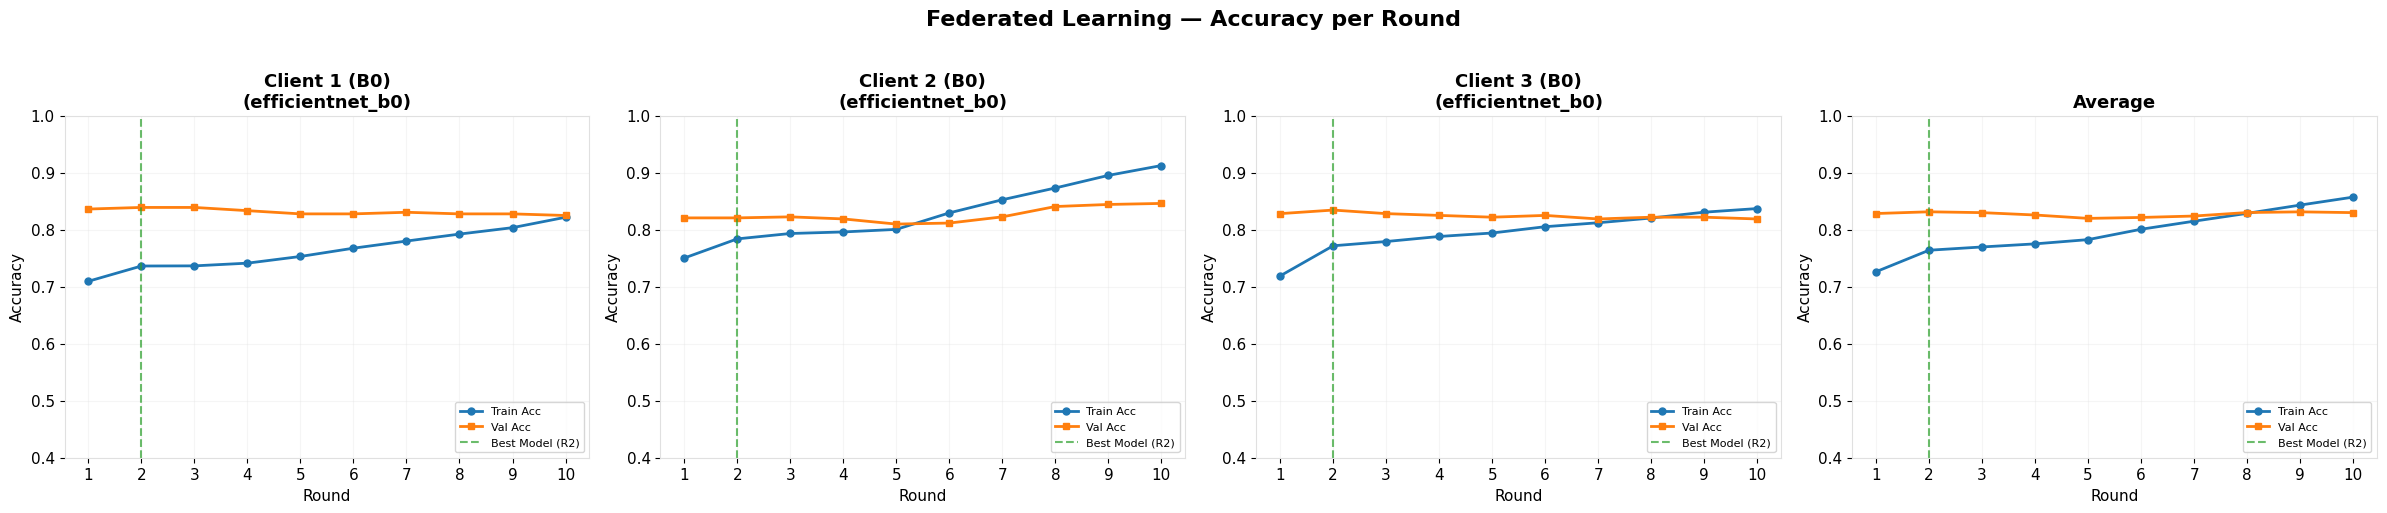

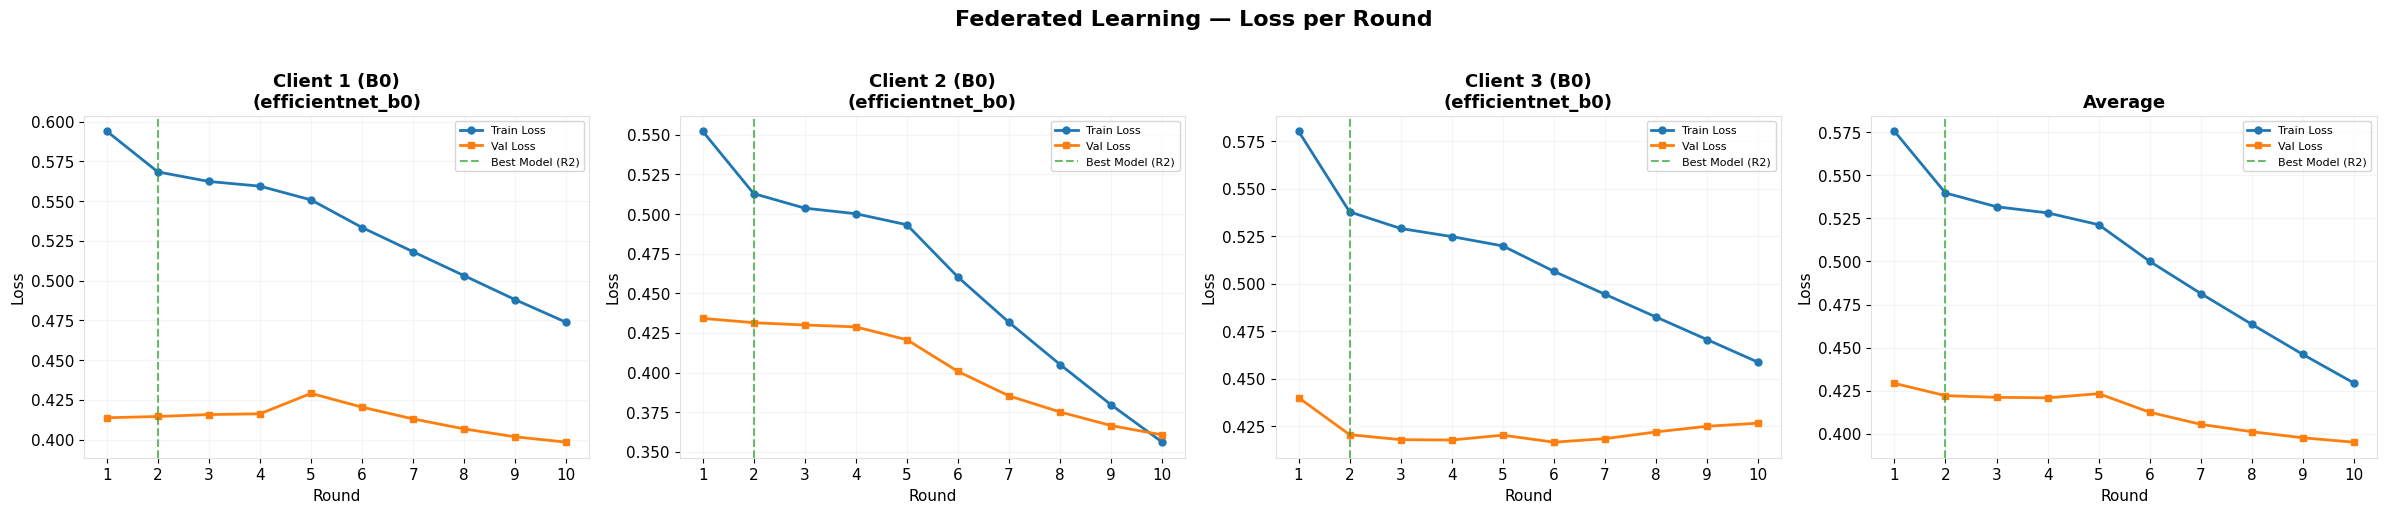

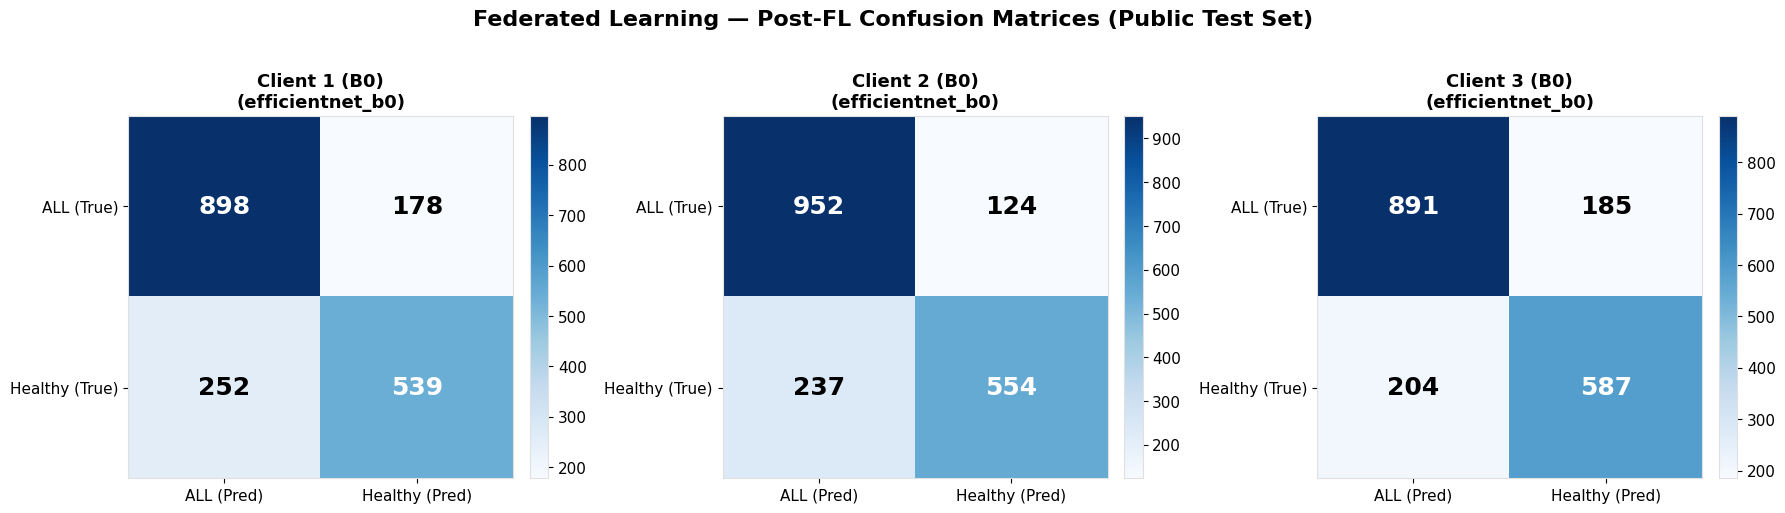


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
FEDERATED LEARNING — POST-FL EVALUATION METRICS (Public Test Set)
═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Client       Model                Accuracy         F1    Precision  Sensitivity  Specificity    ROC-AUC     PR-AUC
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Client 1 (B0) efficientnet_b0        77.0%     80.7%       78.1%       83.5%       68.1%     83.8%     84.8%
Client 2 (B0) efficientnet_b0        80.7%     84.1%       80.1%       88.5%       70.0%     86.0%     86.7%
Client 3 (B0) efficientnet_b0        79.2%     82.1%       81.4%       82.8%       74.2%     86.5%     87.9%
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [16]:
# ─── Simple Theme Setup ───
import matplotlib.pyplot as plt
import matplotlib
import os
import json
import numpy as np

plt.style.use('default')
COLORS = {
    'train': '#1f77b4', 'val': '#ff7f0e', 'best': '#2ca02c',
    'accent': '#d62728', 'bg': '#ffffff', 'grid': '#e0e0e0', 'text': '#000000',
}
matplotlib.rcParams.update({
    'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg'],
    'axes.edgecolor': COLORS['grid'], 'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'], 'xtick.color': COLORS['text'],
    'ytick.color': COLORS['text'], 'grid.color': COLORS['grid'], 'grid.alpha': 0.5,
    'font.size': 11, 'axes.titlesize': 13, 'figure.titlesize': 16,
})

# ─── Load Local Metrics ───
config_path = os.getenv("FLEX_MED_CONFIG_FILE", "flex_med/utils/client_data.json")
with open(config_path) as f:
    config_data = json.load(f)
clients = config_data.get('clients', config_data) if isinstance(config_data, dict) else config_data

metrics_path = os.path.join(os.path.dirname(config_path), "client_simulation_metrics.json")
if not os.path.exists(metrics_path):
    raise RuntimeError(f"Metrics file not found at {metrics_path}. Run the FL simulation first.")

with open(metrics_path, 'r') as f:
    metrics_store = json.load(f)

client_data = {}
for client in clients:
    client_id_str = str(client.get('id', ''))
    if client_id_str in metrics_store:
        client_data[client['client_name']] = {
            'model': client['model_type'], 'metrics': metrics_store[client_id_str]
        }

# ─── FL Per-Round Data Extraction ───
def _extract_round_metrics(r: dict) -> tuple:
    """Nested layout (training / validation) matches fl_simulation_standalone; local file
    helpers used flat keys + val_metrics — support both so curves plot correctly."""
    t = r.get('training') or {}
    v = r.get('validation')
    if v is None:
        v = r.get('val_metrics') or {}
    train_acc = t.get('train_accuracy')
    if train_acc is None:
        train_acc = r.get('train_accuracy')
    val_acc = v.get('accuracy')
    train_loss = t.get('train_loss')
    if train_loss is None:
        train_loss = r.get('train_loss')
    val_loss = v.get('loss')
    if val_loss is None:
        val_loss = t.get('val_loss')
    if val_loss is None:
        val_loss = r.get('val_loss')
    return train_acc, val_acc, train_loss, val_loss

client_names = list(client_data.keys())
n_clients = len(client_names)

_round_lens = [len(d['metrics'].get('rounds', [])) for d in client_data.values()]
num_rounds = max(_round_lens) if _round_lens else 0
rounds_x = list(range(1, num_rounds + 1))

round_data = {}
for name in client_names:
    rounds = sorted(client_data[name]['metrics'].get('rounds', []), key=lambda r: r.get('round', 0))
    if rounds:
        rows = [_extract_round_metrics(r) for r in rounds]
        ta, va, tl, vl = zip(*rows)
        round_data[name] = {
            'train_acc': list(ta), 'val_acc': list(va),
            'train_loss': list(tl), 'val_loss': list(vl),
        }
    else:
        round_data[name] = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

# Compute averages across clients
avg_data = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
for r_idx in range(num_rounds):
    for key in avg_data:
        vals = [round_data[n][key][r_idx] for n in client_names
                if r_idx < len(round_data[n][key]) and round_data[n][key][r_idx] is not None]
        avg_data[key].append(sum(vals) / len(vals) if vals else None)

# Find best round (highest average validation accuracy)
best_round = None
best_val_acc = -1
for i, v in enumerate(avg_data['val_acc']):
    if v is not None and v > best_val_acc:
        best_val_acc = v
        best_round = i + 1

all_plots = [(n, round_data[n]) for n in client_names] + [('Average', avg_data)]

# ─── Figure 1: Accuracy Curves ───
fig, axes = plt.subplots(1, n_clients + 1, figsize=(6 * (n_clients + 1), 5))
fig.suptitle('Federated Learning — Accuracy per Round', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, rd) in enumerate(all_plots):
    ax = axes[idx]
    ax.plot(rounds_x, rd['train_acc'], color=COLORS['train'], marker='o', ms=5, lw=2, label='Train Acc')
    ax.plot(rounds_x, rd['val_acc'], color=COLORS['val'], marker='s', ms=5, lw=2, label='Val Acc')
    if best_round:
        ax.axvline(x=best_round, color=COLORS['best'], ls='--', alpha=0.7, label=f'Best Model (R{best_round})')
    lbl = f"\n({client_data[name]['model']})" if name in client_data else ""
    ax.set_title(f'{name}{lbl}', fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)
    ax.set_xticks(rounds_x); ax.set_ylim(0.4, 1.0)
plt.tight_layout(); plt.show()

# ─── Figure 2: Loss Curves ───
fig, axes = plt.subplots(1, n_clients + 1, figsize=(6 * (n_clients + 1), 5))
fig.suptitle('Federated Learning — Loss per Round', fontsize=16, fontweight='bold', y=1.02)

for idx, (name, rd) in enumerate(all_plots):
    ax = axes[idx]
    ax.plot(rounds_x, rd['train_loss'], color=COLORS['train'], marker='o', ms=5, lw=2, label='Train Loss')
    ax.plot(rounds_x, rd['val_loss'], color=COLORS['val'], marker='s', ms=5, lw=2, label='Val Loss')
    if best_round:
        ax.axvline(x=best_round, color=COLORS['best'], ls='--', alpha=0.7, label=f'Best Model (R{best_round})')
    lbl = f"\n({client_data[name]['model']})" if name in client_data else ""
    ax.set_title(f'{name}{lbl}', fontweight='bold')
    ax.set_xlabel('Round'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.3)
    ax.set_xticks(rounds_x)
plt.tight_layout(); plt.show()

# ─── Figure 3: Confusion Matrices (Post-FL) ───
fig, axes = plt.subplots(1, n_clients, figsize=(6 * n_clients, 5))
if n_clients == 1: axes = [axes]
fig.suptitle('Federated Learning — Post-FL Confusion Matrices (Public Test Set)',
             fontsize=16, fontweight='bold', y=1.02)

for idx, name in enumerate(client_names):
    post_fl = client_data[name]['metrics']['global']['post_fl']
    cm = post_fl.get('confusion_matrix', {})
    TP = cm.get('TP', 0); FP = cm.get('FP', 0)
    FN = cm.get('FN', 0); TN = cm.get('TN', 0)
    matrix = np.array([[TP, FN], [FP, TN]])

    ax = axes[idx]
    im = ax.imshow(matrix, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['ALL (Pred)', 'Healthy (Pred)'])
    ax.set_yticklabels(['ALL (True)', 'Healthy (True)'])
    ax.set_title(f'{name}\n({client_data[name]["model"]})', fontweight='bold')

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                    fontsize=18, fontweight='bold',
                    color='white' if matrix[i, j] > matrix.max() / 2 else 'black')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# ─── FL Metrics Table ───
print(f"\n{'═' * 125}")
print("FEDERATED LEARNING — POST-FL EVALUATION METRICS (Public Test Set)")
print(f"{'═' * 125}")
header = f"{'Client':<12} {'Model':<18} {'Accuracy':>10} {'F1':>10} {'Precision':>12} {'Sensitivity':>12} {'Specificity':>12} {'ROC-AUC':>10} {'PR-AUC':>10}"
print(header)
print(f"{'─' * 125}")

sums = {'accuracy': 0, 'f1_score': 0, 'precision': 0, 'recall': 0, 'specificity': 0, 'roc_auc': 0, 'pr_auc': 0}
auc_counts = {'roc_auc': 0, 'pr_auc': 0}
for name in client_names:
    pf = client_data[name]['metrics']['global']['post_fl']
    roc_val = pf.get('roc_auc')
    pr_val = pf.get('pr_auc')
    roc_str = f"{roc_val:>9.1%}" if roc_val is not None else f"{'N/A':>9}"
    pr_str  = f"{pr_val:>9.1%}" if pr_val is not None else f"{'N/A':>9}"
    print(f"{name:<12} {client_data[name]['model']:<18} "
          f"{pf.get('accuracy', 0):>9.1%} {pf.get('f1_score', 0):>9.1%} "
          f"{pf.get('precision', 0):>11.1%} {pf.get('recall', 0):>11.1%} "
          f"{pf.get('specificity', 0):>11.1%} {roc_str} {pr_str}")
    for k in ['accuracy', 'f1_score', 'precision', 'recall', 'specificity']: sums[k] += pf.get(k, 0)
    if roc_val is not None: sums['roc_auc'] += roc_val; auc_counts['roc_auc'] += 1
    if pr_val is not None:  sums['pr_auc'] += pr_val;  auc_counts['pr_auc'] += 1

n = len(client_names)
avg_roc = f"{sums['roc_auc']/auc_counts['roc_auc']:>9.1%}" if auc_counts['roc_auc'] else f"{'N/A':>9}"
avg_pr  = f"{sums['pr_auc']/auc_counts['pr_auc']:>9.1%}" if auc_counts['pr_auc'] else f"{'N/A':>9}"
print(f"{'─' * 125}")
print(f"{'AVERAGE':<12} {'':<18} "
      f"{sums['accuracy']/n:>9.1%} {sums['f1_score']/n:>9.1%} "
      f"{sums['precision']/n:>11.1%} {sums['recall']/n:>11.1%} "
      f"{sums['specificity']/n:>11.1%} {avg_roc} {avg_pr}")
print(f"{'═' * 125}")

# ─── Mean ± Std Across Seeds (from saved JSON snapshots) ───
import glob, math
_seed_dir = os.path.join(os.getcwd(), 'federated_learning', 'results')
_seed_files = sorted(glob.glob(os.path.join(_seed_dir, 'seed_*.json')))
if _seed_files:
    _seed_data = []
    for _p in _seed_files:
        with open(_p) as _f:
            _seed_data.append(json.load(_f))
    _metric_keys = ['accuracy', 'f1_score', 'precision', 'recall', 'specificity', 'roc_auc', 'pr_auc']
    _per_seed_means = {k: [] for k in _metric_keys}
    for _row in _seed_data:
        _pfl = _row.get('post_fl') or {}
        for _k in _metric_keys:
            _vals = [float(v) for _cid, _m in _pfl.items() if isinstance(_m, dict) and _m.get(_k) is not None for v in [_m[_k]]]
            if _vals: _per_seed_means[_k].append(sum(_vals) / len(_vals))
    _seeds_found = [int(_r['dirichlet_seed']) for _r in _seed_data]
    print(f"\n{'═' * 80}")
    print(f"MEAN \u00b1 STD ACROSS SEEDS {_seeds_found} (client-averaged per seed)")
    print(f"{'═' * 80}")
    for _k in _metric_keys:
        _v = _per_seed_means[_k]
        if not _v: continue
        _mean = sum(_v) / len(_v)
        _std = math.sqrt(sum((x - _mean)**2 for x in _v) / len(_v))
        print(f"  {_k:>16}: {_mean:.4f} \u00b1 {_std:.4f}  (n_seeds={len(_v)})")
    print(f"{'═' * 80}")
else:
    print("\n[INFO] No seed snapshots found in federated_learning/results/ — run aggregate_seeds.py after all seed runs complete.")

---
## 13. Kill Server Process

In [17]:
!fuser -k 8000/tcp
print("Killed processes on port 8000. Re-run the ngrok cell to restart.")

Killed processes on port 8000. Re-run the ngrok cell to restart.
